# ControlGym Scatter Plot

This notebook mirrors `scatter_plot.ipynb`, but it loads a linear system from `controlgym` instead of sampling a synthetic one. Because `controlgym` uses the same disturbance in both the state update and the observation, the Kalman baseline below uses a correlated-noise steady-state predictor.

Before running this notebook, make sure `controlgym` is installed in the same environment as this repo.


In [1]:
import sys
from pathlib import Path

project_root = next((path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'exp').exists()), None)
if project_root is None:
    raise RuntimeError("Could not find project root containing 'exp'.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from scipy.linalg import solve_discrete_are
from torch.optim.lr_scheduler import StepLR

from exp.ARmodel import TwoLayerLinearAR
from exp.controlgym_adapter import (
    CONTROLGYM_LINEAR_SYSTEM_IDS,
    load_controlgym_linear_system,
    screen_controlgym_linear_systems,
    simulate_controlgym_linear_system,
)
from exp.dataloader import make_dataset


In [2]:
candidate_ids = ["cm1", "rea", "umv", "iss", "toy", "ac1", "ac2", "ac3", "ac4", "ac6"]
screen_controlgym_linear_systems(candidate_ids)[
    [
        "env_id",
        "n",
        "p",
        "m",
        "spectral_radius",
        "is_observable",
        "is_controllable",
        "cross_cov_norm",
    ]
]


,env_id,n,p,m,spectral_radius,is_observable,is_controllable,cross_cov_norm
0,toy,2,1,1,1.000000,True,True,0.000000
1,ac3,4,1,2,1.294236,False,True,0.009975
2,ac1,5,3,3,1.000000,True,True,0.000000
3,ac2,5,3,3,1.000000,True,True,0.000000
4,rea,8,1,1,1.066536,False,False,0.010310
5,umv,8,2,2,0.998895,True,True,0.000000
6,ac4,9,1,2,1.017386,True,False,0.000000
7,ac6,10,4,5,1.001223,True,True,0.000000
8,cm1,20,1,2,0.999999,True,True,0.006451
9,iss,270,3,3,0.999688,False,False,0.000004


In [3]:
env_ids = ["ac1", "umv", "ac6"]

sample_time = 0.1
noise_cov = 0.05
random_init_state_cov = 0.1

L = 10
horizons = [1, 5]
plot_state_index = 1

train_T = 10000
test_T = 1000
epochs = 150
batch_size = 64
lr = 0.05
step_size = 2
gamma = 0.9
weight_decay = 1e-3

train_seed = 10
torch_seed = 20
test_seed = 30
test_umode = "ramp_sine"

systems = {
    env_id: load_controlgym_linear_system(
        env_id,
        sample_time=sample_time,
        noise_cov=noise_cov,
        random_init_state_cov=random_init_state_cov,
        seed=0,
    )
    for env_id in env_ids
}

fig_dir = project_root / "notebooks" / "figs"
fig_dir.mkdir(parents=True, exist_ok=True)

selected_envs = screen_controlgym_linear_systems(env_ids)[
    [
        "env_id",
        "n",
        "p",
        "m",
        "spectral_radius",
        "is_observable",
        "is_controllable",
        "cross_cov_norm",
    ]
]

print(f"Available controlgym linear ids: {len(CONTROLGYM_LINEAR_SYSTEM_IDS)}")
print(f"Running env_ids={env_ids}")
selected_envs


Available controlgym linear ids: 37
Running env_ids=['ac1', 'umv', 'ac6']


,env_id,n,p,m,spectral_radius,is_observable,is_controllable,cross_cov_norm
0,ac1,5,3,3,1.000000,True,True,0.0
1,umv,8,2,2,0.998895,True,True,0.0
2,ac6,10,4,5,1.001223,True,True,0.0


In [4]:
def steady_state_kalman_predictor_gain_correlated(A, C, W, V, N):
    """Return the steady-state predictor gain for correlated process/measurement noise."""

    A = np.asarray(A, dtype=float)
    C = np.asarray(C, dtype=float)
    W = np.asarray(W, dtype=float)
    V = np.asarray(V, dtype=float)
    N = np.asarray(N, dtype=float)

    P = solve_discrete_are(A.T, C.T, W, V, s=N)
    S = C @ P @ C.T + V
    L = (A @ P @ C.T + N) @ np.linalg.inv(S)
    return L, P, S


def run_steady_state_kalman_filter_correlated(
    A,
    B,
    C,
    W,
    V,
    N,
    initial_state_mean,
    control_inputs,
    measurements,
):
    """Return predicted means aligned with the dataset windows."""

    L, _, _ = steady_state_kalman_predictor_gain_correlated(A, C, W, V, N)

    x = np.asarray(initial_state_mean, dtype=float).copy()
    predicted_means = [x]

    for u_t, y_t in zip(control_inputs, measurements[:-1]):
        innovation = y_t - C @ x
        x = A @ x + B @ u_t + L @ innovation
        predicted_means.append(x)

    return np.asarray(predicted_means)[:-1], L


def simulate_kalman_trajectory(
    system,
    T,
    *,
    seed,
    u_mode=None,
    u_scale=2.0,
    period=50,
):
    _, Y, U = simulate_controlgym_linear_system(
        system,
        T,
        seed=seed,
        u_mode=u_mode,
        u_scale=u_scale,
        period=period,
    )
    kf_pred_x, _ = run_steady_state_kalman_filter_correlated(
        system.A,
        system.B,
        system.C,
        system.W,
        system.V,
        system.N,
        system.init_state,
        U,
        Y,
    )
    return Y, U, kf_pred_x


def compute_coordinate_r2(true_states, predicted_states):
    residual_ss = np.sum((true_states - predicted_states) ** 2, axis=0)
    centered_true_states = true_states - true_states.mean(axis=0, keepdims=True)
    total_ss = np.sum(centered_true_states ** 2, axis=0)

    coordinate_r2 = np.full(true_states.shape[1], np.nan)
    valid = total_ss > 0
    coordinate_r2[valid] = 1.0 - residual_ss[valid] / total_ss[valid]
    return coordinate_r2


def train_controlgym_scatter(
    system,
    *,
    L,
    H,
    train_T,
    test_T,
    epochs,
    batch_size,
    lr,
    step_size,
    gamma,
    weight_decay,
    train_seed,
    torch_seed,
    test_seed,
    test_umode,
):
    n = system.A.shape[0]
    p = system.B.shape[1]
    m = system.C.shape[0]

    train_Y, train_U, train_kf_x = simulate_kalman_trajectory(
        system,
        train_T + H,
        seed=train_seed,
    )
    train_loader, _, _, _ = make_dataset(
        L,
        H,
        train_Y,
        train_U,
        train_kf_x,
        batch_size=batch_size,
    )

    torch.manual_seed(torch_seed)
    model = TwoLayerLinearAR((m + p) * L, n, m * H)

    criterion = nn.MSELoss(reduction="sum")
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)

    losses = []
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0

        for batch_inputs, batch_outputs in train_loader:
            outputs, _ = model(batch_inputs)
            loss = criterion(outputs, batch_outputs)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        average_loss = total_loss / len(train_loader.dataset)
        losses.append(float(average_loss))
        print(
            f"Epoch [{epoch + 1}/{epochs}], Training Loss: {average_loss:.4f}, "
            f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}"
        )
        scheduler.step()

    model.eval()
    test_Y, test_U, test_kf_x = simulate_kalman_trajectory(
        system,
        test_T + H,
        seed=test_seed,
        u_mode=test_umode,
        u_scale=2.0,
        period=40,
    )
    _, test_inputs_np, _, test_kf_states_np = make_dataset(
        L,
        H,
        test_Y,
        test_U,
        test_kf_x,
        batch_size=batch_size,
    )

    feature_matrix = test_inputs_np @ model.linear1.weight.detach().cpu().numpy().T
    coeff, _, _, _ = np.linalg.lstsq(feature_matrix, test_kf_states_np, rcond=None)
    predicted_states = feature_matrix @ coeff
    coeff_rank = int(np.linalg.matrix_rank(coeff))
    print("coefficient rank:", coeff_rank)

    return model, test_kf_states_np, predicted_states, losses


def plot_scatter(kf_states, learned_states, *, state_index, label, save_path=None):
    x_kf = kf_states[:, state_index]
    x_act = learned_states[:, state_index]

    plt.figure(figsize=(6, 6))
    plt.scatter(x_kf, x_act, s=10, alpha=0.6, label=label)

    vmin = min(np.min(x_kf), np.min(x_act))
    vmax = max(np.max(x_kf), np.max(x_act))
    plt.plot([vmin, vmax], [vmin, vmax], linestyle="--", linewidth=1)
    plt.grid(True)
    plt.xlabel("Kalman Filter Predicted State Estimate", fontsize=18)
    plt.ylabel("Learned Activations", fontsize=18)
    plt.legend(fontsize=18)

    if save_path is not None:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")

    plt.show()


In [5]:
h1_results = {}

for env_id in env_ids:
    system = systems[env_id]
    n = system.A.shape[0]
    p = system.B.shape[1]
    m = system.C.shape[0]

    print(f"\nTraining env_id={env_id!r} with n={n}, p={p}, m={m} and H=1")
    print(f"spectral_radius(A)={np.max(np.abs(np.linalg.eigvals(system.A))):.4f}")
    print(f"||N||_F={np.linalg.norm(system.N, ord='fro'):.4f}")

    model_h1, kf_states_h1, act_states_h1, losses_h1 = train_controlgym_scatter(
        system,
        L=L,
        H=1,
        train_T=train_T,
        test_T=test_T,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        step_size=step_size,
        gamma=gamma,
        weight_decay=weight_decay,
        train_seed=train_seed,
        torch_seed=torch_seed,
        test_seed=test_seed,
        test_umode=test_umode,
    )

    h1_results[env_id] = {
        "model": model_h1,
        "kf_states": kf_states_h1,
        "act_states": act_states_h1,
        "losses": losses_h1,
        "n": n,
    }



Training env_id='ac1' with n=5, p=3, m=3 and H=1
spectral_radius(A)=1.0000
||N||_F=0.0000
Epoch [1/150], Training Loss: 63.3840, Learning Rate: 0.050000
Epoch [2/150], Training Loss: 0.0799, Learning Rate: 0.050000
Epoch [3/150], Training Loss: 3.7591, Learning Rate: 0.045000
Epoch [4/150], Training Loss: 0.3774, Learning Rate: 0.045000
Epoch [5/150], Training Loss: 0.0471, Learning Rate: 0.040500
Epoch [6/150], Training Loss: 0.1704, Learning Rate: 0.040500
Epoch [7/150], Training Loss: 0.8287, Learning Rate: 0.036450
Epoch [8/150], Training Loss: 4.1303, Learning Rate: 0.036450
Epoch [9/150], Training Loss: 0.0357, Learning Rate: 0.032805
Epoch [10/150], Training Loss: 0.0307, Learning Rate: 0.032805
Epoch [11/150], Training Loss: 0.0307, Learning Rate: 0.029525
Epoch [12/150], Training Loss: 0.0285, Learning Rate: 0.029525
Epoch [13/150], Training Loss: 0.0264, Learning Rate: 0.026572
Epoch [14/150], Training Loss: 0.0332, Learning Rate: 0.026572
Epoch [15/150], Training Loss: 0.02

ac1 H=1 coordinate R^2: [0.9921 0.9998 0.9913 0.7727 0.6595]


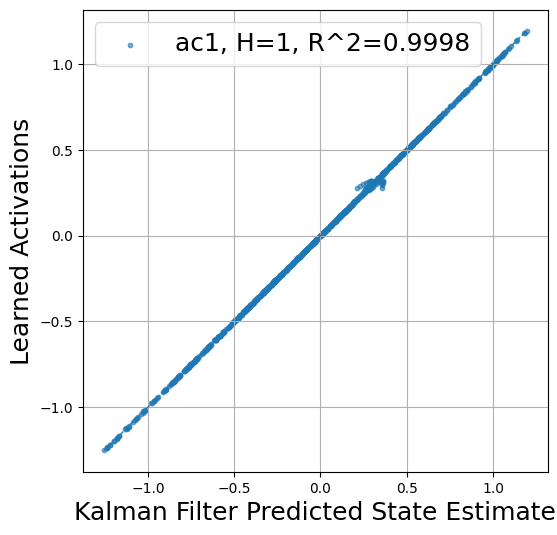

umv H=1 coordinate R^2: [0.9999 0.9806 0.9999 0.9999 0.9804 0.9999 1.     0.9997]


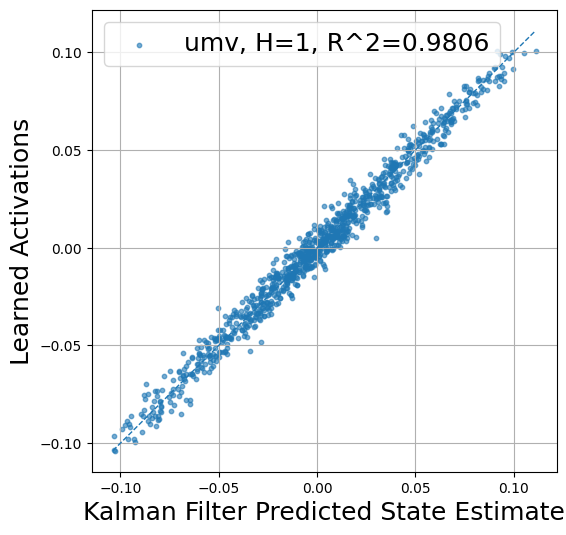

ac6 H=1 coordinate R^2: [0.9998 0.9919 0.9959 0.9916 0.997  0.9965 0.998  0.9987 0.9981 0.821 ]


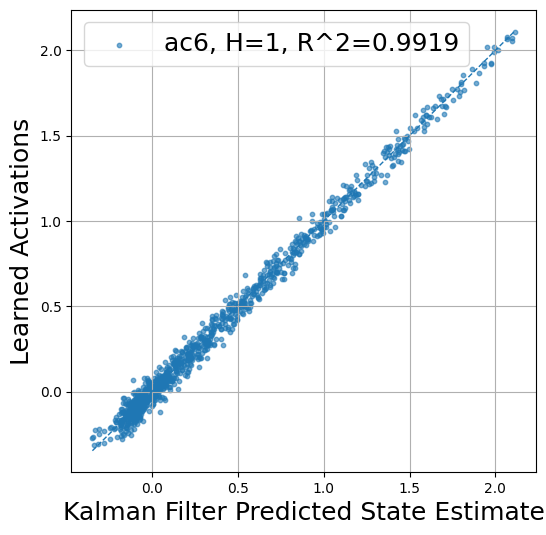

In [6]:
r2_h1_by_env = {}

for env_id in env_ids:
    result = h1_results[env_id]
    state_index = min(plot_state_index, result["n"] - 1)
    r2_h1 = compute_coordinate_r2(result["kf_states"], result["act_states"])
    r2_h1_by_env[env_id] = r2_h1
    print(f"{env_id} H=1 coordinate R^2: {np.round(r2_h1, 4)}")
    plot_scatter(
        result["kf_states"],
        result["act_states"],
        state_index=state_index,
        label=f"{env_id}, H=1, R^2={r2_h1[state_index]:.4f}",
        save_path=fig_dir / f"controlgym_scatter_{env_id}_h1.png",
    )


In [7]:
h5_results = {}

for env_id in env_ids:
    system = systems[env_id]
    n = system.A.shape[0]
    p = system.B.shape[1]
    m = system.C.shape[0]

    print(f"\nTraining env_id={env_id!r} with n={n}, p={p}, m={m} and H=5")
    print(f"spectral_radius(A)={np.max(np.abs(np.linalg.eigvals(system.A))):.4f}")
    print(f"||N||_F={np.linalg.norm(system.N, ord='fro'):.4f}")

    model_h5, kf_states_h5, act_states_h5, losses_h5 = train_controlgym_scatter(
        system,
        L=L,
        H=5,
        train_T=train_T,
        test_T=test_T,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        step_size=step_size,
        gamma=gamma,
        weight_decay=weight_decay,
        train_seed=train_seed,
        torch_seed=torch_seed,
        test_seed=test_seed,
        test_umode=test_umode,
    )

    h5_results[env_id] = {
        "model": model_h5,
        "kf_states": kf_states_h5,
        "act_states": act_states_h5,
        "losses": losses_h5,
        "n": n,
    }



Training env_id='ac1' with n=5, p=3, m=3 and H=5
spectral_radius(A)=1.0000
||N||_F=0.0000
Epoch [1/150], Training Loss: 459.3102, Learning Rate: 0.050000
Epoch [2/150], Training Loss: 5.3167, Learning Rate: 0.050000
Epoch [3/150], Training Loss: 4.2064, Learning Rate: 0.045000
Epoch [4/150], Training Loss: 7.1031, Learning Rate: 0.045000
Epoch [5/150], Training Loss: 2.1042, Learning Rate: 0.040500
Epoch [6/150], Training Loss: 0.6076, Learning Rate: 0.040500
Epoch [7/150], Training Loss: 0.4451, Learning Rate: 0.036450
Epoch [8/150], Training Loss: 0.5448, Learning Rate: 0.036450
Epoch [9/150], Training Loss: 0.3717, Learning Rate: 0.032805
Epoch [10/150], Training Loss: 0.9883, Learning Rate: 0.032805
Epoch [11/150], Training Loss: 0.1625, Learning Rate: 0.029525
Epoch [12/150], Training Loss: 0.3247, Learning Rate: 0.029525
Epoch [13/150], Training Loss: 0.1295, Learning Rate: 0.026572
Epoch [14/150], Training Loss: 0.1828, Learning Rate: 0.026572
Epoch [15/150], Training Loss: 0.3

ac1 H=5 coordinate R^2: [0.992  0.9998 0.9913 0.7753 0.6593]


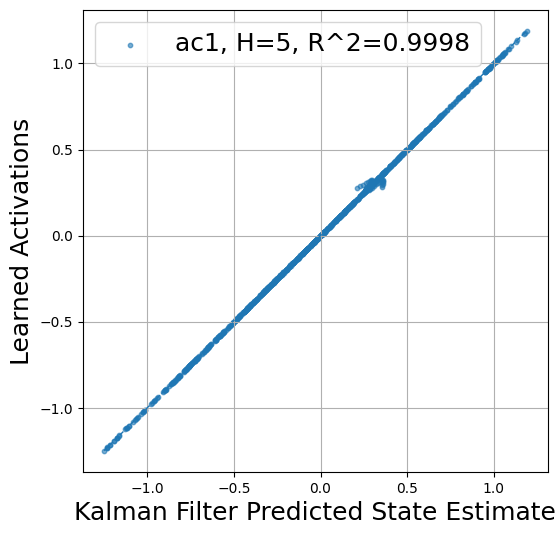

umv H=5 coordinate R^2: [0.9999 0.9744 0.9999 0.9999 0.9741 0.9999 1.     0.9997]


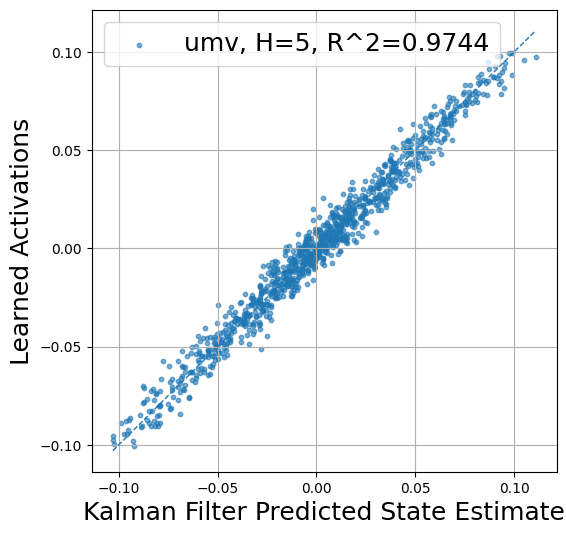

ac6 H=5 coordinate R^2: [0.9998 0.991  0.9961 0.9907 0.9957 0.9952 0.9965 0.9978 0.9967 0.8364]


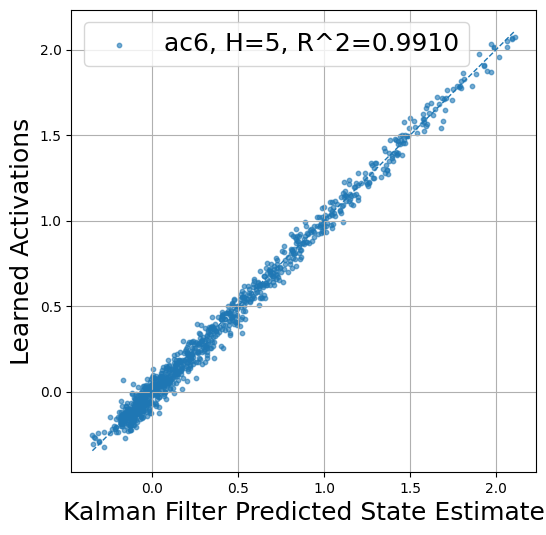

In [8]:
r2_h5_by_env = {}

for env_id in env_ids:
    result = h5_results[env_id]
    state_index = min(plot_state_index, result["n"] - 1)
    r2_h5 = compute_coordinate_r2(result["kf_states"], result["act_states"])
    r2_h5_by_env[env_id] = r2_h5
    print(f"{env_id} H=5 coordinate R^2: {np.round(r2_h5, 4)}")
    plot_scatter(
        result["kf_states"],
        result["act_states"],
        state_index=state_index,
        label=f"{env_id}, H=5, R^2={r2_h5[state_index]:.4f}",
        save_path=fig_dir / f"controlgym_scatter_{env_id}_h5.png",
    )


In [9]:
r2_summaries = {}

for env_id in env_ids:
    r2_summary = pd.DataFrame(
        [r2_h1_by_env[env_id], r2_h5_by_env[env_id]],
        index=["H=1", "H=5"],
        columns=[f"state_{i}_r2" for i in range(r2_h1_by_env[env_id].shape[0])],
    )
    r2_summary["mean_r2"] = r2_summary.mean(axis=1)
    r2_summaries[env_id] = r2_summary
    print(f"\nR^2 summary for {env_id}")
    display(r2_summary.round(3))



R^2 summary for ac1


,state_0_r2,state_1_r2,state_2_r2,state_3_r2,state_4_r2,mean_r2
H=1,0.992,1.0,0.991,0.773,0.660,0.883
H=5,0.992,1.0,0.991,0.775,0.659,0.884



R^2 summary for umv


,state_0_r2,state_1_r2,state_2_r2,state_3_r2,state_4_r2,state_5_r2,state_6_r2,state_7_r2,mean_r2
H=1,1.0,0.981,1.0,1.0,0.980,1.0,1.0,1.0,0.995
H=5,1.0,0.974,1.0,1.0,0.974,1.0,1.0,1.0,0.993



R^2 summary for ac6


,state_0_r2,state_1_r2,state_2_r2,state_3_r2,state_4_r2,state_5_r2,state_6_r2,state_7_r2,state_8_r2,state_9_r2,mean_r2
H=1,1.0,0.992,0.996,0.992,0.997,0.997,0.998,0.999,0.998,0.821,0.979
H=5,1.0,0.991,0.996,0.991,0.996,0.995,0.997,0.998,0.997,0.836,0.980
